<a href="https://colab.research.google.com/github/Yennhinn/github-portfolio/blob/main/Red_Wine_Quality.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Preparation

In [1]:
# importting Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings as wr
wr.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (confusion_matrix, accuracy_score,
                             roc_curve, roc_auc_score, ConfusionMatrixDisplay)
from sklearn.tree import plot_tree

In [5]:
# loading and reading dataset
df = pd.read_csv("winequality-red.csv")
print(df.head())

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4        5  
1      9.8        5  
2      9.8        5 

In [6]:
# shape of the data
df.shape

(1599, 12)

In [7]:
#data information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [8]:
# describing the data
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [9]:
#column to list
df.columns.tolist()
# check for missing values:
df.isnull().sum()
#checking duplicate values
df.nunique()

,0
fixed acidity,96
volatile acidity,143
citric acid,80
residual sugar,91
chlorides,153
free sulfur dioxide,60
total sulfur dioxide,144
density,436
pH,89
sulphates,96


# EDA

## 1. Quality Distribution



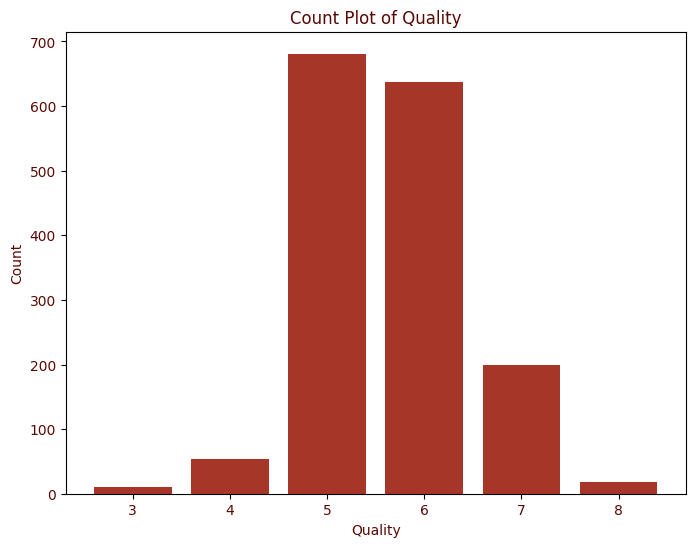

In [10]:
# Assuming 'df' is your DataFrame
quality_counts = df['quality'].value_counts()

# Using Matplotlib to create a count plot
plt.figure(figsize=(8, 6))
plt.bar(quality_counts.index, quality_counts, color='#a63728')  # Change color to red
plt.title('Count Plot of Quality', color='#590904')  # Dark color for title
plt.xlabel('Quality', color='#590904')  # Dark color for x-label
plt.ylabel('Count', color='#590904')  # Dark color for y-label
plt.xticks(color='#590904')  # Dark color for x-tick labels
plt.yticks(color='#590904')  # Dark color for y-tick labels
plt.show()


## Boxplot

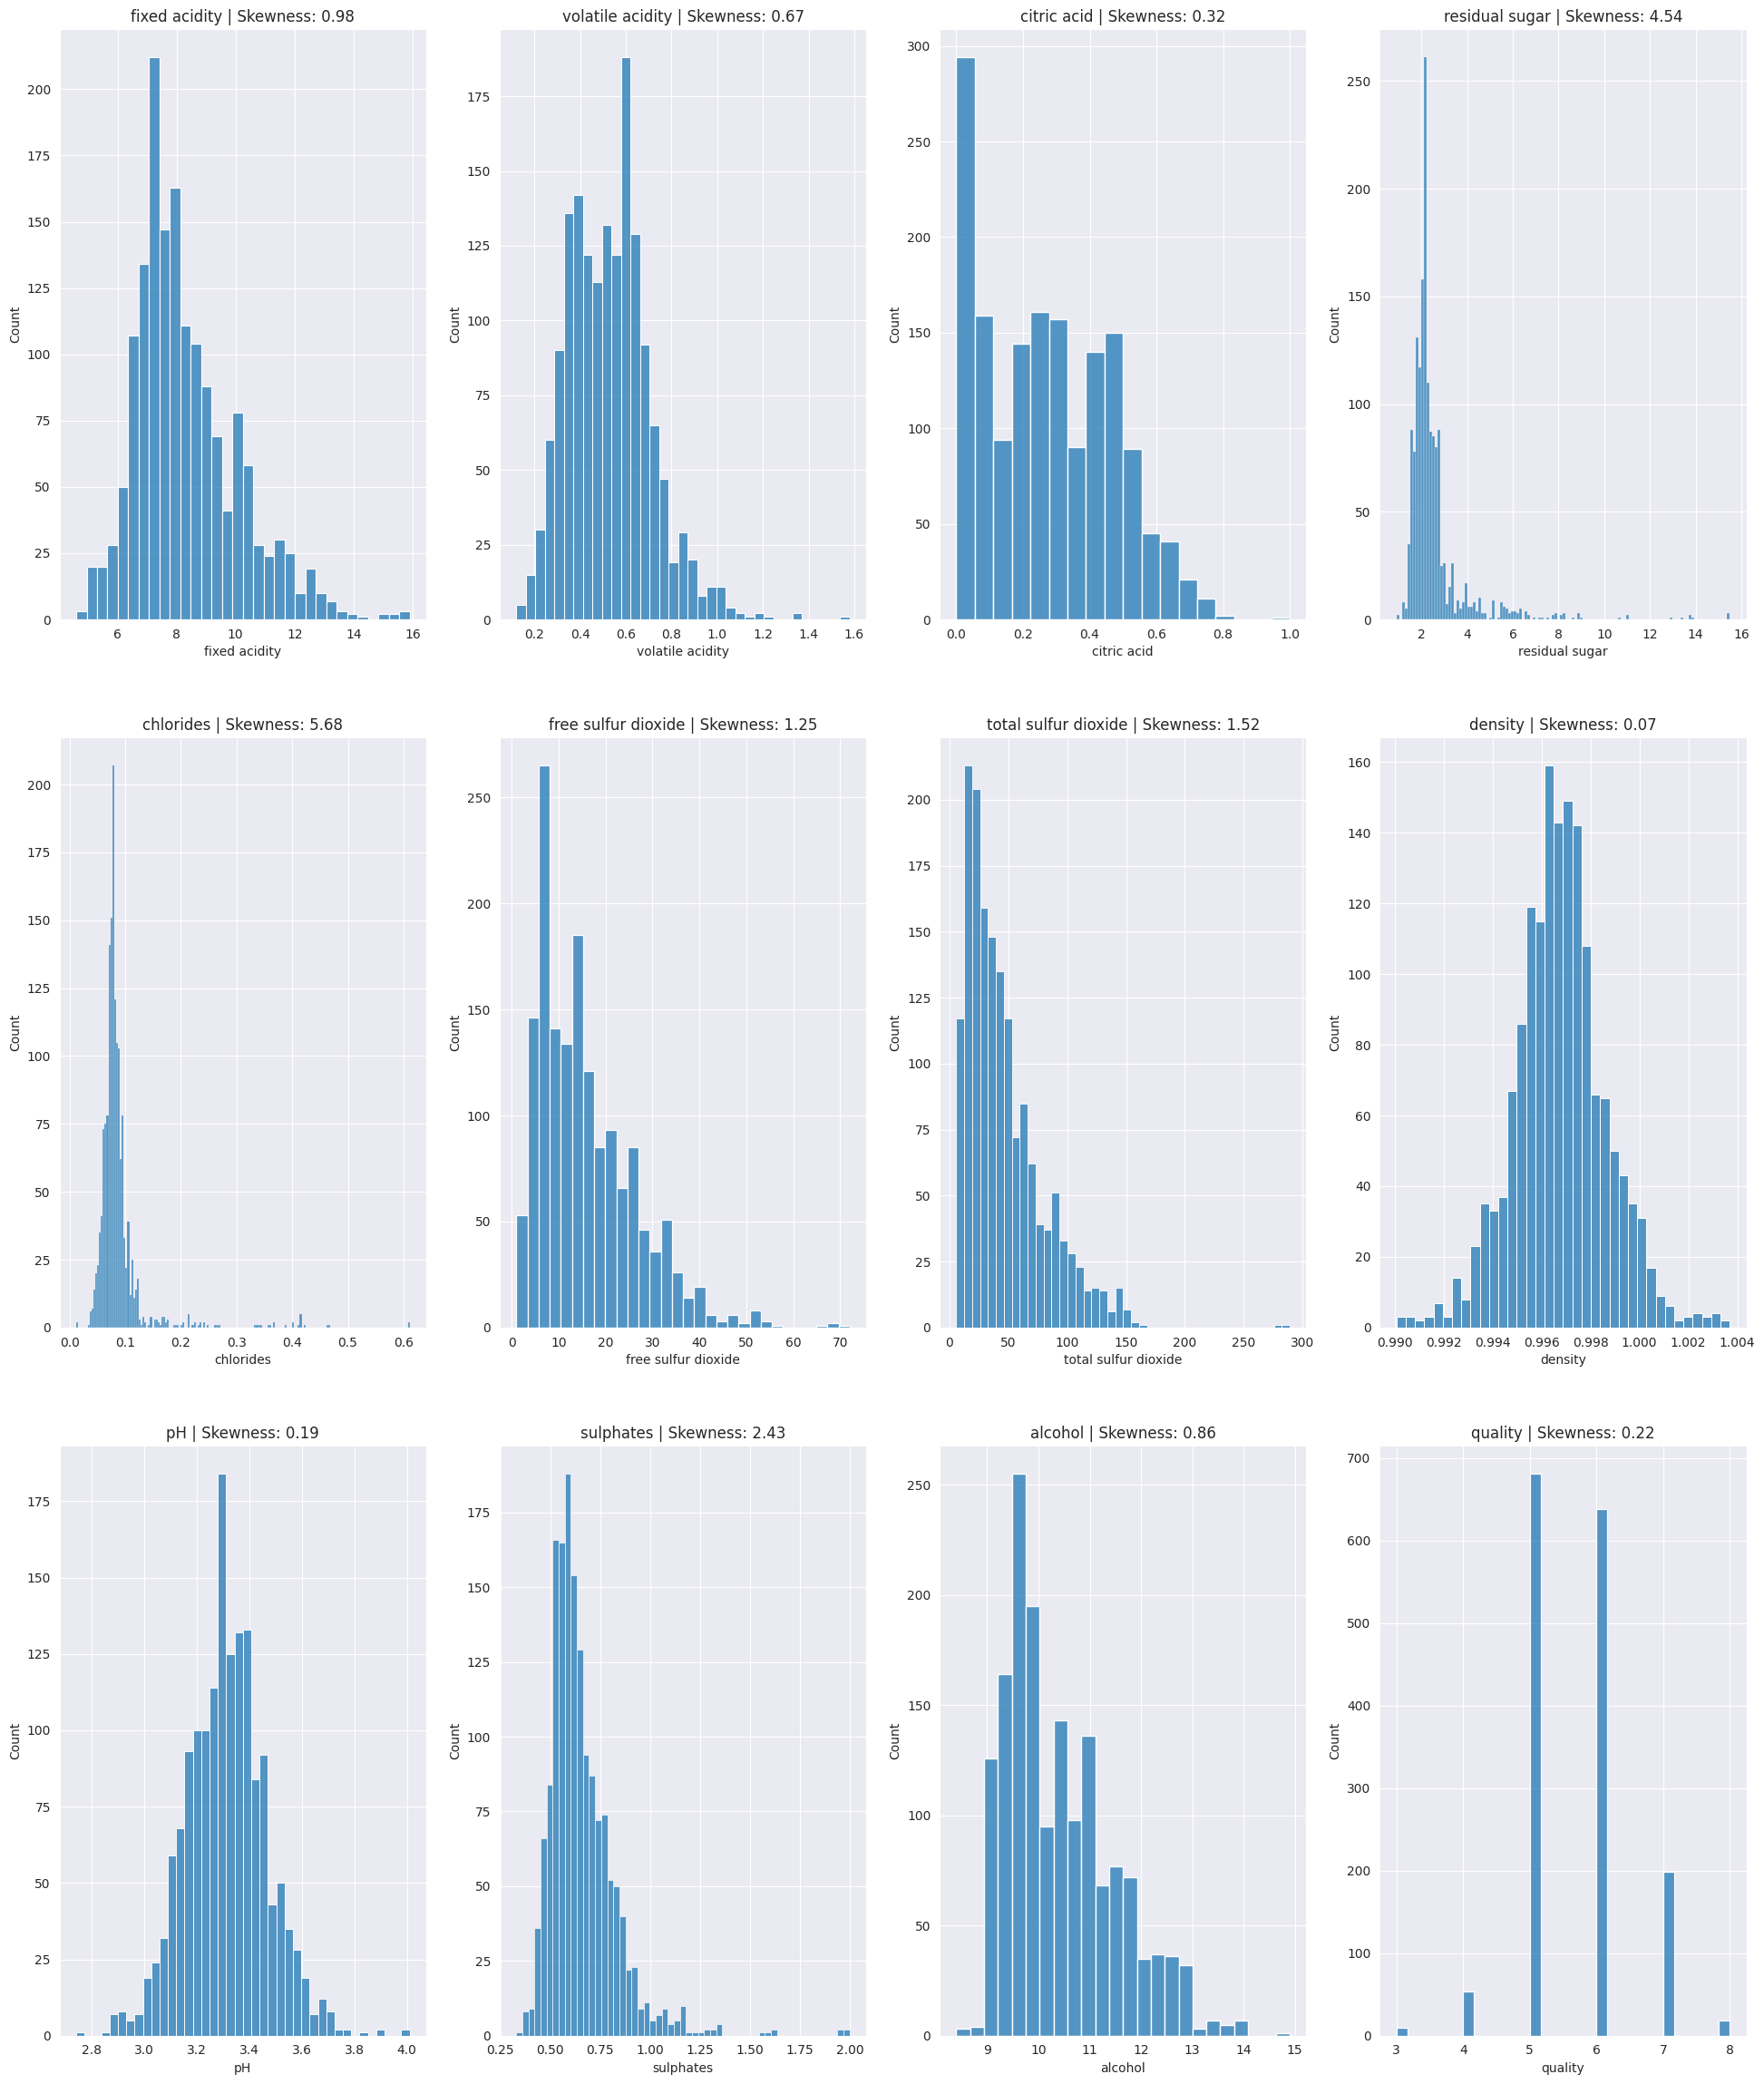

In [11]:
# Set Seaborn style
sns.set_style("darkgrid")

# Identify numerical columns
numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns

# Plot distribution of each numerical feature
plt.figure(figsize=(24, len(numerical_columns) * 10))
for idx, feature in enumerate(numerical_columns, 1):
    plt.subplot(len(numerical_columns), 4, idx)
    sns.histplot(df[feature])
    plt.title(f"{feature} | Skewness: {round(df[feature].skew(), 2)}")

## Boxplot by quality?

<Figure size 640x480 with 0 Axes>

<Figure size 1500x1000 with 0 Axes>

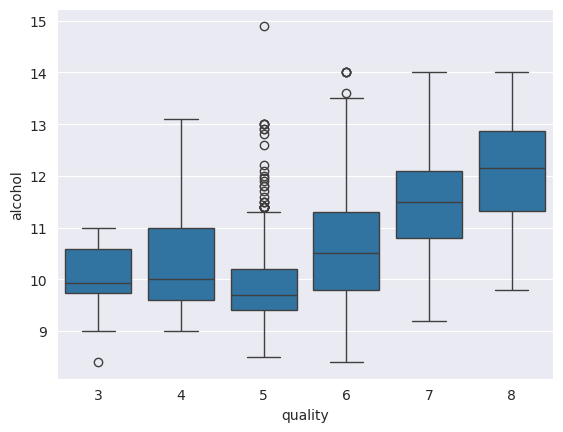

<Figure size 1500x1000 with 0 Axes>

In [12]:
# Adjust layout and show plots
plt.tight_layout()
plt.show()

#plotting box plot between alcohol and quality
sns.boxplot(x='quality', y='alcohol', data=df, order=sorted(df['quality'].unique()))

# Assuming 'df' is your DataFrame
plt.figure(figsize=(15, 10))


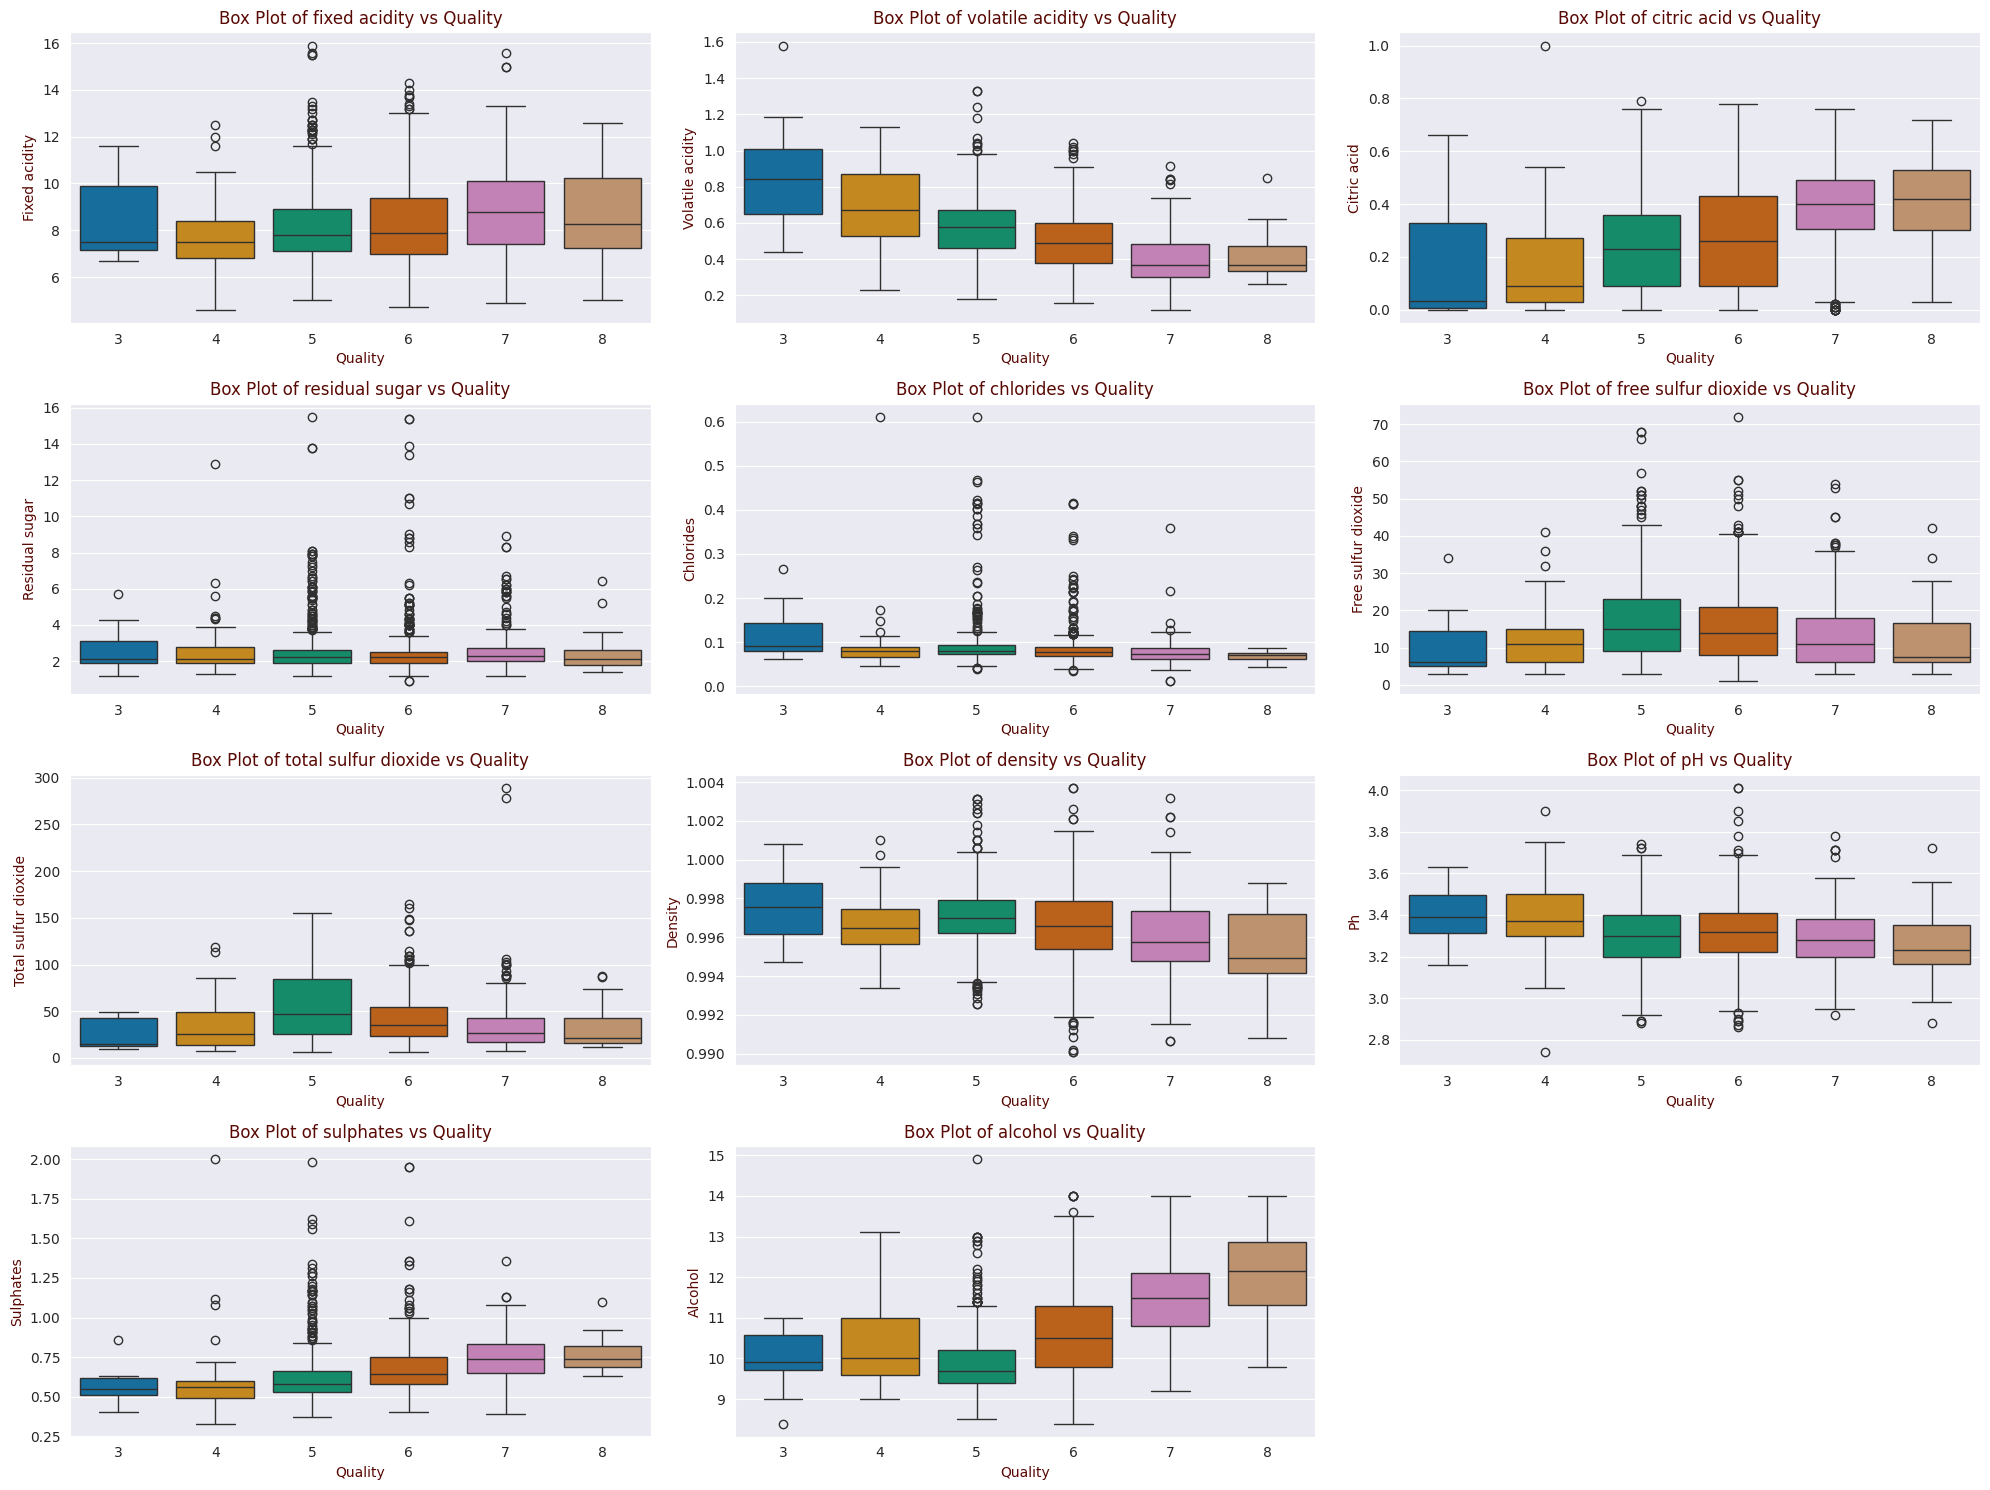

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd # Import pandas for DataFrame operations

# Assuming your data is in a CSV file named 'winequality-red.csv'
# Replace 'winequality-red.csv' with your actual file name if different
df = pd.read_csv('winequality-red.csv') # Load data into a DataFrame named 'df'


# List of attributes to plot
attributes = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
              'chlorides', 'free sulfur dioxide', 'total sulfur dioxide',
              'density', 'pH', 'sulphates', 'alcohol']

# Set up the matplotlib figure
plt.figure(figsize=(20, 15))

# Loop through each attribute and create a box plot
for i, attribute in enumerate(attributes):
    plt.subplot(4, 3, i + 1)  # Create a grid of 4 rows and 3 columns
    sns.boxplot(x='quality', y=attribute, data=df, order=sorted(df['quality'].unique()), palette='colorblind')
    plt.title(f'Box Plot of {attribute} vs Quality', color='#590904')  # Dark color for title
    plt.xlabel('Quality', color='#590904')  # Dark color for x-label
    plt.ylabel(attribute.capitalize(), color='#590904')  # Dark color for y-label

# Adjust layout
plt.tight_layout()
plt.show()

# Correlation Matrix


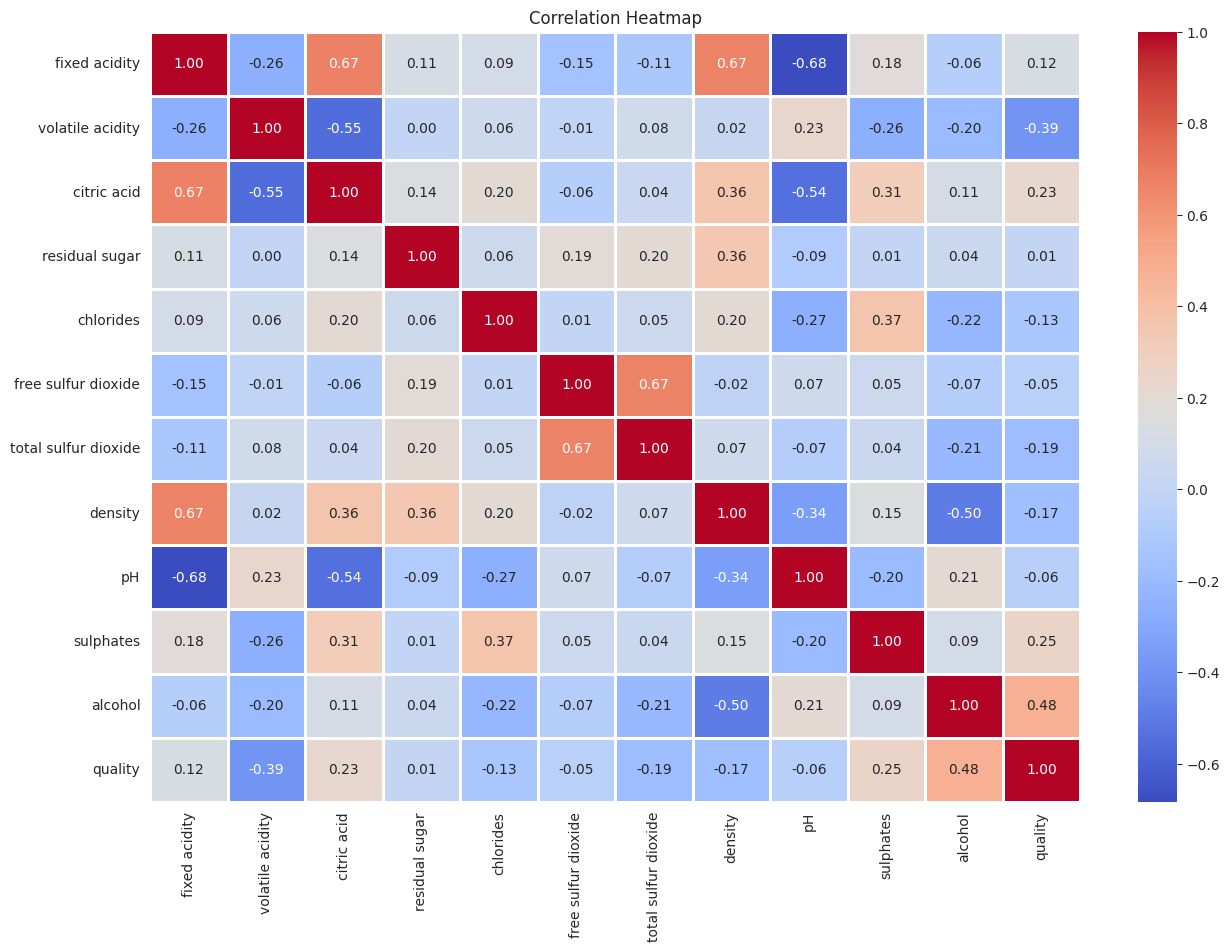

In [14]:
# Using Seaborn to create a heatmap
plt.figure(figsize=(15, 10))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=2)
plt.title('Correlation Heatmap')
plt.show()

# Modeling


In [16]:
# Split the data into training (1400) and testing (199) sets
train, test = train_test_split(df, test_size=199/1599, random_state=42)

In [17]:
# Linear regression to predict wine quality (numerical data)
# Separating input features and target variable
X_train = train.drop('quality', axis=1)
y_train = train['quality']
X_test = test.drop('quality', axis=1)
y_test = test['quality']

# Linear Regression model
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

# Get the equation of the line
intercept = linear_model.intercept_
coefficients = linear_model.coef_

print(f"Intercept (b): {intercept}")
print(f"Coefficients (slope): {coefficients}")

# Predicting on test data
y_pred_linear = linear_model.predict(X_test)

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred_linear)
mse = mean_squared_error(y_test, y_pred_linear)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_linear)

print(f'MAE (Mean Absolute Error): {mae}')
print(f'MSE (Mean Squared Error): {mse}')
print(f'RMSE (Root Mean Squared Error): {rmse}')
print(f'R^2 (R-squared): {r2}')

Intercept (b): 12.67683706435222
Coefficients (slope): [ 2.11876808e-02 -1.05793606e+00 -1.48698571e-01  8.54070792e-03
 -1.69475942e+00  5.18687422e-03 -3.49184007e-03 -8.82921987e+00
 -3.26237146e-01  8.85243953e-01  2.76513540e-01]
MAE (Mean Absolute Error): 0.49608028255399983
MSE (Mean Squared Error): 0.3900419400228992
RMSE (Root Mean Squared Error): 0.6245333778293193
R^2 (R-squared): 0.41975766841296647


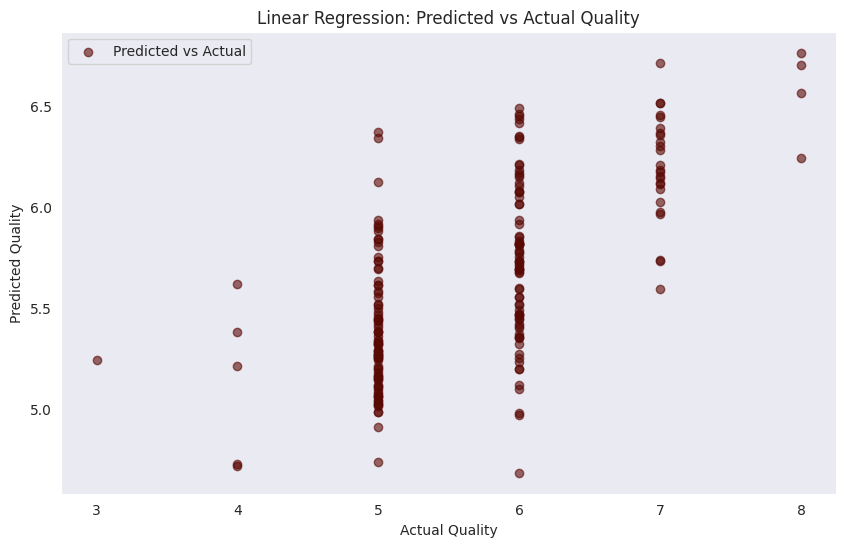

In [18]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_linear, color='#590904', label='Predicted vs Actual', alpha=0.6)  # Dark color for points
plt.title('Linear Regression: Predicted vs Actual Quality')
plt.xlabel('Actual Quality')
plt.ylabel('Predicted Quality')
plt.legend()
plt.grid()
plt.show()

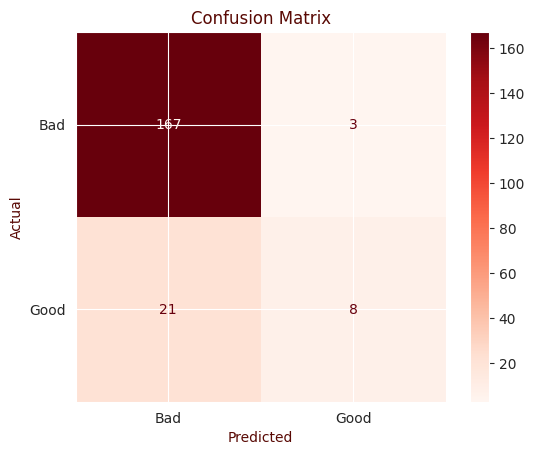

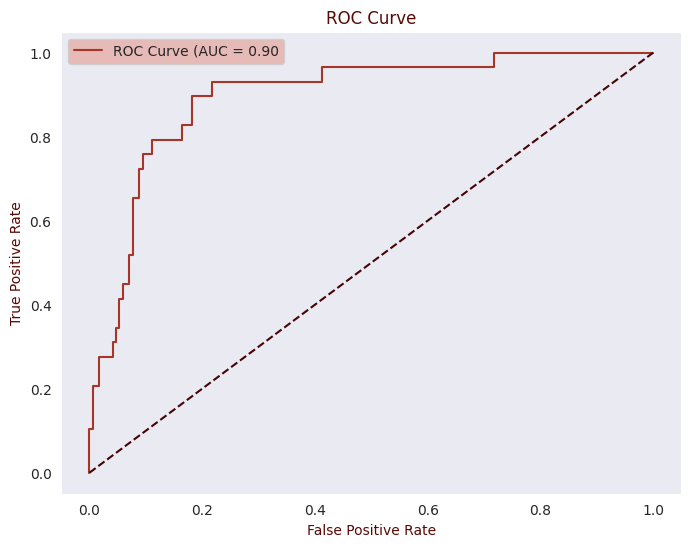

Logistic Regression Accuracy: 0.88


In [19]:
# Adding a binary column for wine quality classification: <6.5 -> 'bad', else 'good'
df['quality_binary'] = df['quality'].apply(lambda x: 'bad' if x < 6.5 else 'good')

# Converting 'quality_binary' to numerical for logistic regression
df['quality_binary_numeric'] = df['quality_binary'].map({'bad': 0, 'good': 1})

# Splitting the data into training and testing sets
X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(
    df.drop(['quality', 'quality_binary', 'quality_binary_numeric'], axis=1),
    df['quality_binary_numeric'],
    test_size=199/1599,
    random_state=42
)

# Logistic Regression model
logistic_model = LogisticRegression(max_iter=1000)
logistic_model.fit(X_train_log, y_train_log)

# Predicting on test data
y_pred_log = logistic_model.predict(X_test_log)
y_prob_log = logistic_model.predict_proba(X_test_log)[:, 1]  # Probabilities for the positive class

# Confusion Matrix
cm = confusion_matrix(y_test_log, y_pred_log)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Bad', 'Good']).plot(cmap='Reds')  # You can customize this further if needed
plt.title('Confusion Matrix', color='#590904')  # Dark color for title
plt.xlabel('Predicted', color='#590904')
plt.ylabel('Actual', color='#590904')
plt.show()

# ROC Curve and AUC
fpr, tpr, thresholds = roc_curve(y_test_log, y_prob_log)
roc_auc = roc_auc_score(y_test_log, y_prob_log)

# ROC Curve and AUC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#a63728', label=f'ROC Curve (AUC = {roc_auc:.2f}')  # Red color for ROC curve
plt.plot([0, 1], [0, 1], color='#460404', linestyle='--')  # Very dark color for diagonal line
plt.title('ROC Curve', color='#590904')  # Dark color for title
plt.xlabel('False Positive Rate', color='#590904')
plt.ylabel('True Positive Rate', color='#590904')
plt.legend(facecolor='#e6afa8')  # Light color for legend background
plt.grid()
plt.show()

# Print accuracy
accuracy = np.mean(y_pred_log == y_test_log)
print(f'Logistic Regression Accuracy: {accuracy:.2f}')

In [20]:
# Logistic regression coefficients
coefficients = logistic_model.coef_[0]
intercept = logistic_model.intercept_[0]
print("Logistic Regression Equation:")
equation = " + ".join([f"{coef:.4f}*x{i}" for i, coef in enumerate(coefficients)]) + f" + {intercept:.4f}"
print(f"P = 1 / (1 + exp(-({equation})))\n")

Logistic Regression Equation:
P = 1 / (1 + exp(-(0.0805*x0 + -2.3746*x1 + 0.3859*x2 + 0.0928*x3 + -1.0499*x4 + 0.0167*x5 + -0.0185*x6 + -0.0541*x7 + -0.1202*x8 + 2.4590*x9 + 0.9642*x10 + -12.9355)))



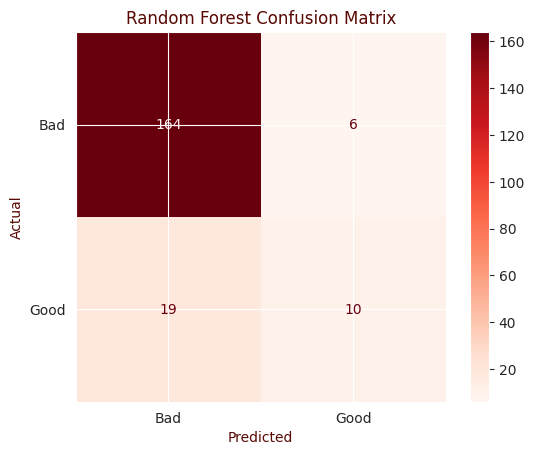

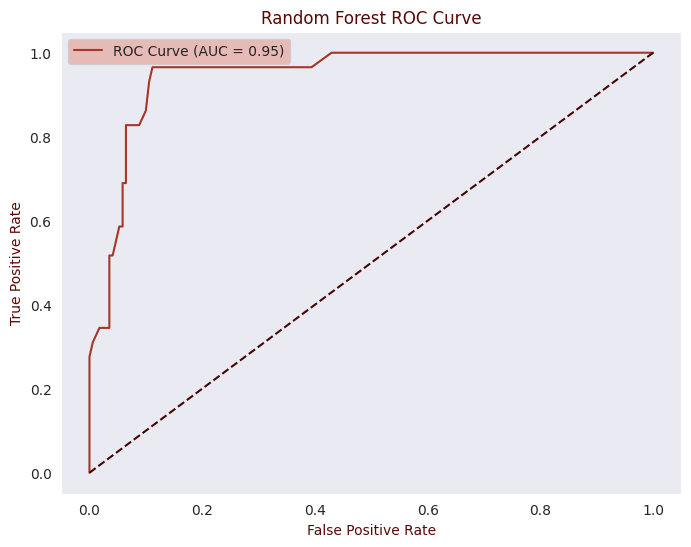

Random Forest Accuracy: 0.87


In [28]:
# Random Forest model
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_log, y_train_log)

# Predicting on test data
y_pred_rf = rf_model.predict(X_test_log)
y_prob_rf = rf_model.predict_proba(X_test_log)[:, 1]  # Probabilities for the positive class

# Confusion Matrix for Random Forest
cm_rf = confusion_matrix(y_test_log, y_pred_rf)
ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['Bad', 'Good']).plot(cmap='Reds')
plt.title('Random Forest Confusion Matrix', color='#590904')
plt.xlabel('Predicted', color='#590904')
plt.ylabel('Actual', color='#590904')
plt.show()

# ROC Curve and AUC for Random Forest
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test_log, y_prob_rf)
roc_auc_rf = roc_auc_score(y_test_log, y_prob_rf)

# ROC Curve for Random Forest
plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, color='#a63728', label=f'ROC Curve (AUC = {roc_auc_rf:.2f})')
plt.plot([0, 1], [0, 1], color='#460404', linestyle='--')
plt.title('Random Forest ROC Curve', color='#590904')
plt.xlabel('False Positive Rate', color='#590904')
plt.ylabel('True Positive Rate', color='#590904')
plt.legend(facecolor='#e6afa8')
plt.grid()
plt.show()

# Print accuracy for Random Forest
accuracy_rf = np.mean(y_pred_rf == y_test_log)
print(f'Random Forest Accuracy: {accuracy_rf:.2f}')


In [22]:
# Visualizing the first tree in the Random Forest
plt.figure(figsize=(120, 80))
plot_tree(rf_model.estimators_[0], feature_names=X_train_log.columns, class_names=['Bad', 'Good'], filled=True)
plt.title('First Tree of the Random Forest')
plt.tight_layout()
plt.show()

In [27]:
# Defining the hyperparameter grid
parameters = {
    'n_neighbors': list(np.arange(3, 50, 2)),  # Odd values between 3 and 49
    'weights': ['uniform', 'distance'],        # Different weighting strategies
    'p': [1, 2, 3, 4]                         # Different distance metrics
}

# Initialize KNN model
knn = KNeighborsClassifier()

# GridSearchCV with 10-fold cross-validation
knn_cv = GridSearchCV(estimator=knn, param_grid=parameters, cv=10)
knn_cv.fit(X_train_log, y_train_log)  # Fitting on training data

# Output the best parameters and best score
print('Tuned hyper parameters: ', knn_cv.best_params_)
print(f'Best cross-validated accuracy: {knn_cv.best_score_:.2f}')


Tuned hyper parameters:  {'n_neighbors': np.int64(17), 'p': 1, 'weights': 'distance'}
Best cross-validated accuracy: 0.91


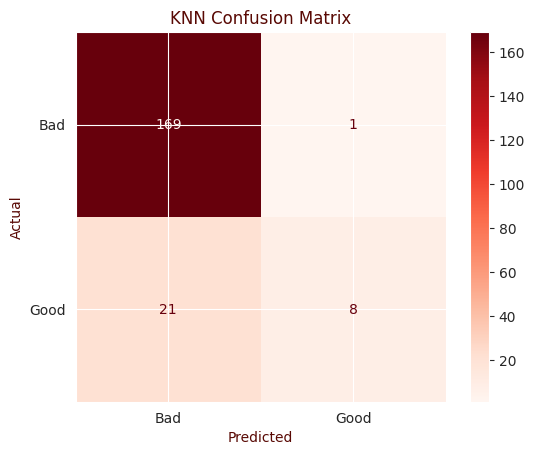

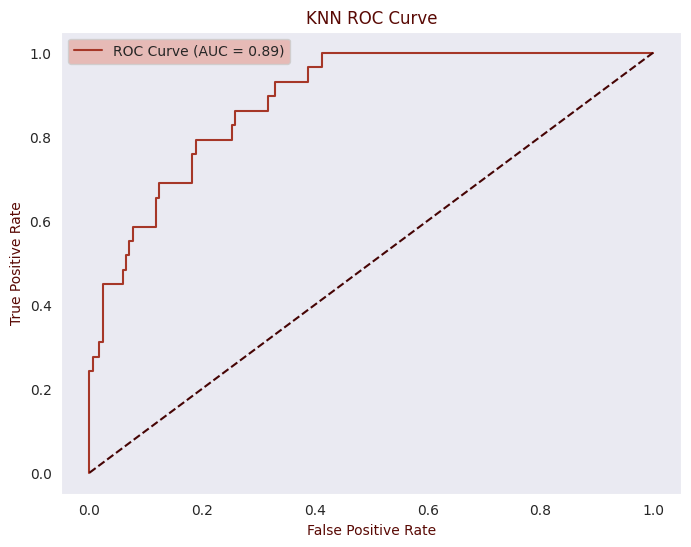

KNN Accuracy: 0.89


In [29]:
# KNN model
knn_model = KNeighborsClassifier(n_neighbors=17, p=1, weights='distance')
knn_model.fit(X_train_log, y_train_log)

# Predicting on test data
y_pred_knn = knn_model.predict(X_test_log)
y_prob_knn = knn_model.predict_proba(X_test_log)[:, 1]  # Probabilities for the positive class

# Confusion Matrix for KNN
cm_knn = confusion_matrix(y_test_log, y_pred_knn)
ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=['Bad', 'Good']).plot(cmap='Reds')
plt.title('KNN Confusion Matrix', color='#590904')
plt.xlabel('Predicted', color='#590904')
plt.ylabel('Actual', color='#590904')
plt.show()

# ROC Curve and AUC for KNN
fpr_knn, tpr_knn, thresholds_knn = roc_curve(y_test_log, y_prob_knn)
roc_auc_knn = roc_auc_score(y_test_log, y_prob_knn)

# ROC Curve for KNN
plt.figure(figsize=(8, 6))
plt.plot(fpr_knn, tpr_knn, color='#a63728', label=f'ROC Curve (AUC = {roc_auc_knn:.2f})')
plt.plot([0, 1], [0, 1], color='#460404', linestyle='--')
plt.title('KNN ROC Curve', color='#590904')
plt.xlabel('False Positive Rate', color='#590904')
plt.ylabel('True Positive Rate', color='#590904')
plt.legend(facecolor='#e6afa8')
plt.grid()
plt.show()

# Print accuracy for KNN
accuracy_knn = np.mean(y_pred_knn == y_test_log)
print(f'KNN Accuracy: {accuracy_knn:.2f}')


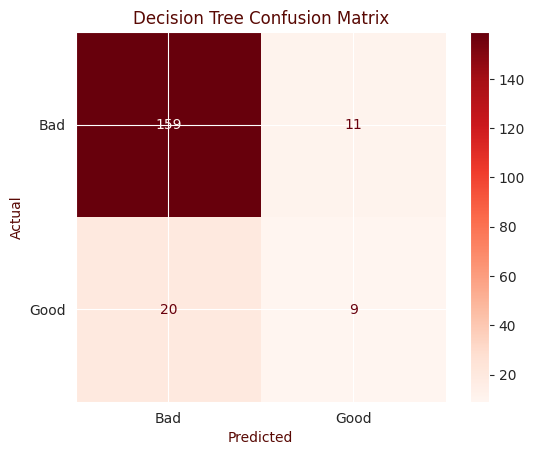

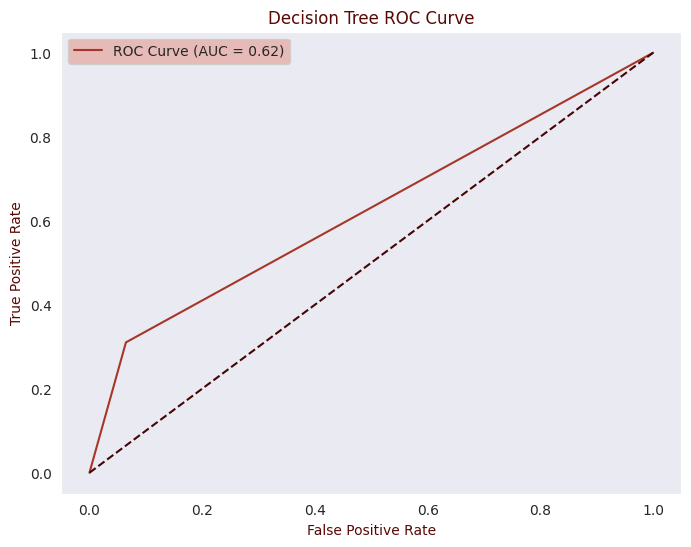

Decision Tree Accuracy: 0.84


In [26]:
# Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_log, y_train_log)

# Predicting on test data
y_pred_dt = dt_model.predict(X_test_log)
y_prob_dt = dt_model.predict_proba(X_test_log)[:, 1]  # Probabilities for the positive class

# Confusion Matrix for Decision Tree
cm_dt = confusion_matrix(y_test_log, y_pred_dt)
ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=['Bad', 'Good']).plot(cmap='Reds')
plt.title('Decision Tree Confusion Matrix', color='#590904')
plt.xlabel('Predicted', color='#590904')
plt.ylabel('Actual', color='#590904')
plt.show()

# ROC Curve and AUC for Decision Tree
fpr_dt, tpr_dt, thresholds_dt = roc_curve(y_test_log, y_prob_dt)
roc_auc_dt = roc_auc_score(y_test_log, y_prob_dt)

# ROC Curve for Decision Tree
plt.figure(figsize=(8, 6))
plt.plot(fpr_dt, tpr_dt, color='#a63728', label=f'ROC Curve (AUC = {roc_auc_dt:.2f})')
plt.plot([0, 1], [0, 1], color='#460404', linestyle='--')
plt.title('Decision Tree ROC Curve', color='#590904')
plt.xlabel('False Positive Rate', color='#590904')
plt.ylabel('True Positive Rate', color='#590904')
plt.legend(facecolor='#e6afa8')
plt.grid()
plt.show()

# Print accuracy for Decision Tree
accuracy_dt = np.mean(y_pred_dt == y_test_log)
print(f'Decision Tree Accuracy: {accuracy_dt:.2f}')
